In [1]:
import numpy as np
import math 
import matplotlib.pyplot as plt
import csv
from csv import writer
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator

In [2]:
# Change the csv file name below, without .csv
# comma separated data

In [3]:
#filename='temperature_log_2024-12-03T16-06-07' # unstable 80 K
#filename='temperature_log_2024-12-09T16-13-39' # good stable 77 K
#filename='temperature_log_2024-12-16T17-01-51' # unstable 78 K
#filename='temperature_log_2024-12-19T04-01-15' # stable 77K 12+ hours long run
filename='temperature_log_2025-01-01T18-41-11' # new year run - SMA cable test 1

In [4]:
data_temp = np.loadtxt(filename+".txt", usecols=1, skiprows=4, dtype='float',delimiter=",") 
data_timestamp = np.loadtxt(filename+".txt", usecols=1, skiprows=4, dtype='str') 
data_date =  np.loadtxt(filename+".txt", usecols=0, skiprows=4, dtype='str') 


In [5]:
time_stamps=np.empty(len(data_timestamp), dtype = 'S20')
for j in range(len(data_timestamp)):
    count=-1
    for i in data_timestamp[j]:
        count+=1
        if i==',':
            #print(count)
            time_stamps[j]=data_timestamp[j][:count]
        
#data_timestamp[0]

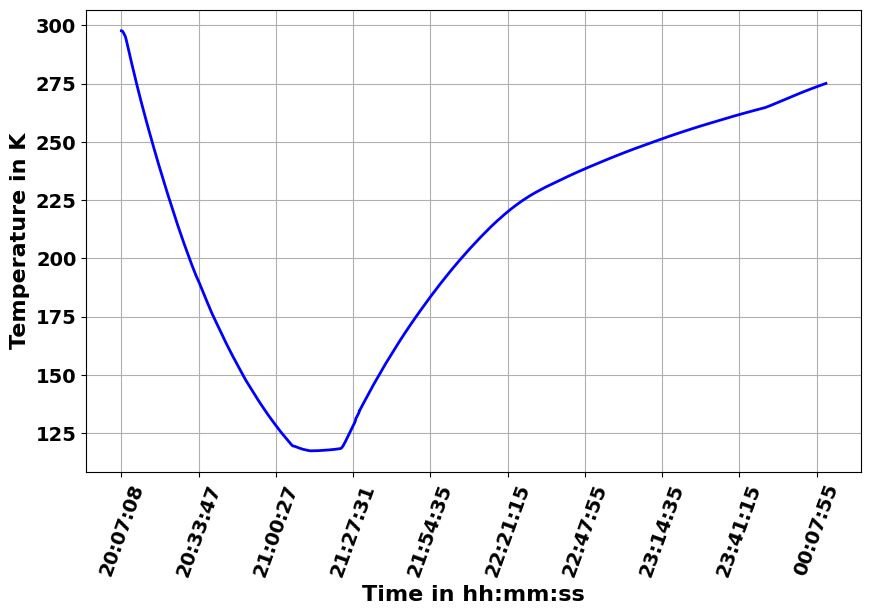

In [6]:
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(time_stamps,data_temp,'b-',linewidth=2)
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
#plt.title("Cryo-cooler temperature curve",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.grid()
plt.show()

In [33]:
counter=0
pressure_readings=np.array([])
date_time=np.array([])
with open('../test_logs/1jan2025'+'.xls', mode ='r')as file:
  csvFile = csv.reader(file)
  for lines in csvFile:
      counter+=1
      if(counter>6):
          lines1=lines[0].split('\t')
          pressure_readings=np.append(pressure_readings,10**3*float(lines1[0]))
          date_time=np.append(date_time,lines1[7])

In [31]:
### Find timestamp index
counter=0
for i in range(len(time_stamps)):
    #print(i)
    if str(time_stamps[i],'utf-8')=='20:07:23':
        print(counter)
        break
    counter+=1

print('Temp at timestamp',str(time_stamps[counter],'utf-8'),'is',data_temp[counter])

2
Temp at timestamp 20:07:23 is 297.6


In [179]:
temp_lowest=-1
for i in data_temp:
    temp_lowest+=1
    if i<77: #81
        print(temp_lowest)
        break

796


In [180]:
temp_lowest_last=-1
for i in data_temp:
    temp_lowest_last+=1
    if i<78: #81.3
        #print(temp_lowest_last)
        temp_lowest_last1=temp_lowest_last
        

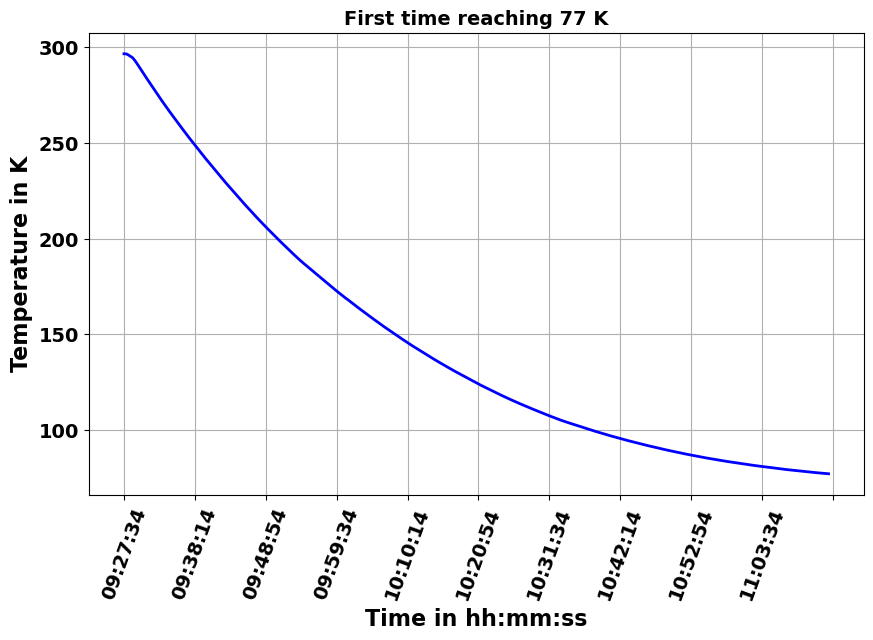

In [181]:
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(time_stamps[:temp_lowest],data_temp[:temp_lowest],'b-',linewidth=2)
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
#plt.title("Cryo-cooler temperature curve",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.title('First time reaching 77 K',fontsize = 14,fontweight='bold')
plt.grid()
plt.show()

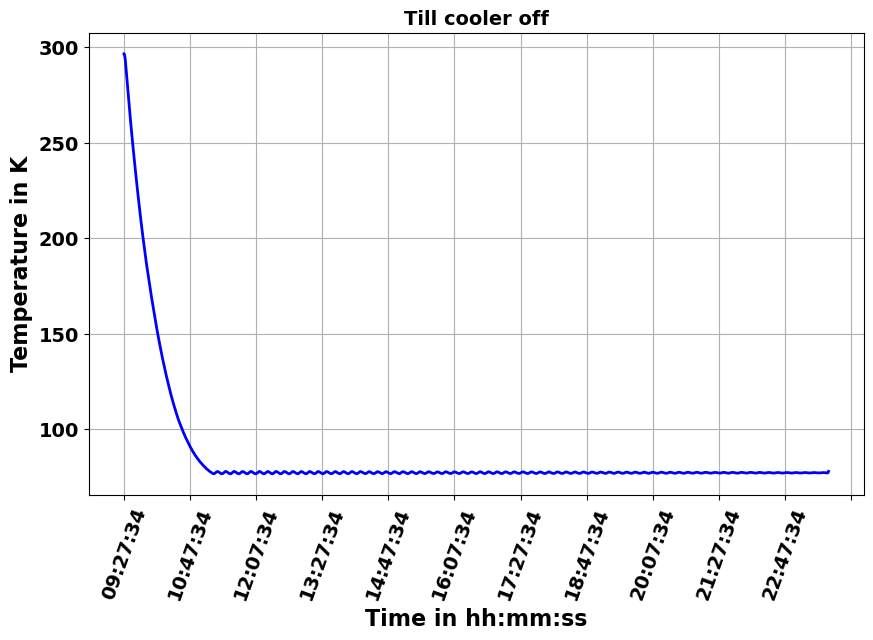

In [182]:
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(time_stamps[:temp_lowest_last1],data_temp[:temp_lowest_last1],'b-',linewidth=2)
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
#plt.title("Cryo-cooler temperature curve",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.title('Till cooler off',fontsize = 14,fontweight='bold')
plt.grid()
plt.show()

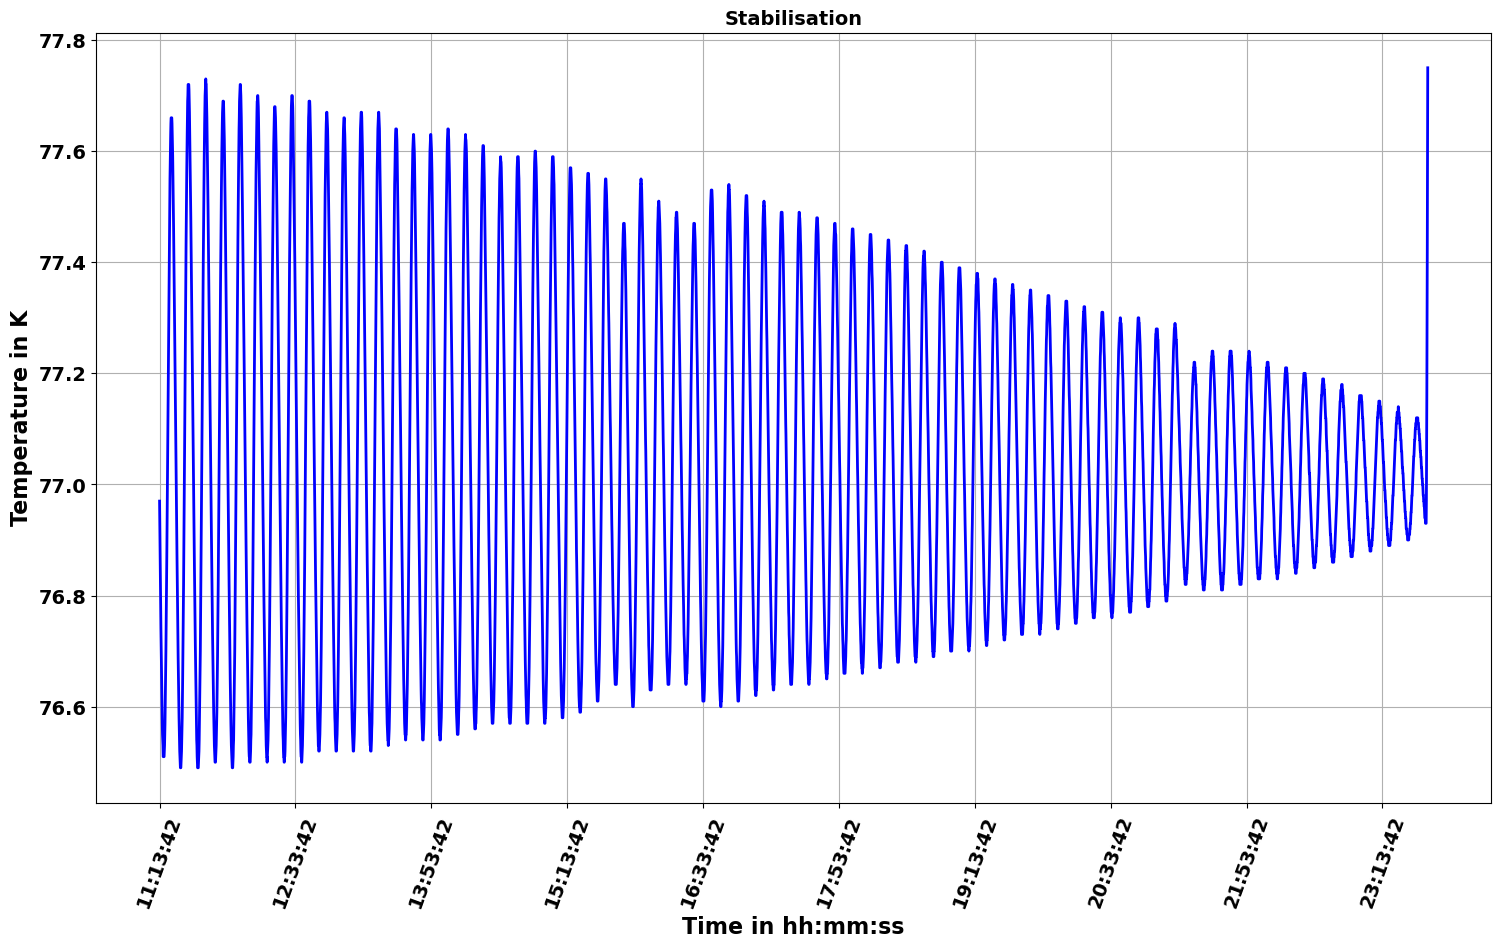

In [187]:
fig,ax=plt.subplots(figsize=(18,10))
plt.plot(time_stamps[temp_lowest:temp_lowest_last1],data_temp[temp_lowest:temp_lowest_last1],'b-',linewidth=2)
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
#plt.title("Cryo-cooler temperature curve",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.title('Stabilisation',fontsize = 14,fontweight='bold')
plt.grid()
plt.show()